# Homework 2

## Problem 1 -  Dollar Profits
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- dollarpos variable below is a DataFrame containing randomly generated initial dollar positions in each symbol at the close of market the prior day. 
- Compute the dollar profit in each symbol on a given day as a DataFrame
- Plot the cumulative dollar profit in A through time

In [1]:
import seaborn as sns
from numpy.ma.core import cumsum

In [2]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

dollarpos = np.random.normal(1000,100, (1000,5))
dollarpos = pd.DataFrame(dollarpos,columns = columns).abs()

In [3]:
rets.head(5)

,A,B,C,D,E
0,0.002978,-0.001886,0.015511,-0.001390,0.000889
1,0.010167,-0.005529,-0.003529,0.001380,-0.001880
2,-0.007315,-0.001092,-0.002062,0.004000,-0.010289
3,-0.004212,0.007451,0.011898,-0.009321,0.004261
4,-0.005979,-0.005199,-0.005294,-0.002463,0.006475


In [4]:
dollarpos.head(5)

,A,B,C,D,E
0,986.883892,1009.945713,963.855726,854.101435,1094.914353
1,1093.872669,995.278760,1130.634236,1039.967874,995.893444
2,988.909846,873.050137,966.428699,922.890901,1106.897311
3,931.551739,903.208327,876.001081,930.647464,902.428986
4,1058.200028,1188.182520,854.963604,845.612332,968.584335


In [5]:
# Profit and Loss dataframe

p_l = rets * dollarpos
p_l.head(5)

,A,B,C,D,E
0,2.938826,-1.904630,14.950204,-1.186875,0.973258
1,11.121520,-5.503108,-3.989497,1.435366,-1.871854
2,-7.234170,-0.953535,-1.992773,3.691496,-11.388611
3,-3.923976,6.730252,10.423097,-8.674680,3.844862
4,-6.326805,-6.177664,-4.526100,-2.082859,6.271965


<Axes: title={'center': 'Cumulative Profit and Loss for Asset "A"'}>

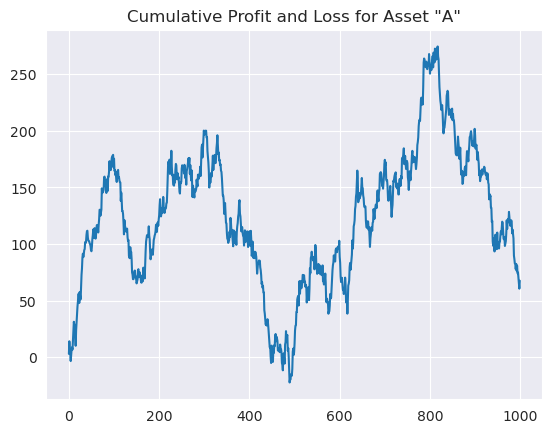

In [6]:
# Plot the cumulative dollar profit in A through time

# create a new cumulative pnl column
p_l['A_cumulative_pnl'] = p_l['A'].cumsum()

# plot the curve vs time
p_l['A_cumulative_pnl'].plot(title='Cumulative Profit and Loss for Asset "A"')


## Problem 2 - Performance Stats 
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- Please complete the function "compute_stats".
- compute_stats takes as input rets and returns a new DataFrame (stats) containing performance stats as specified below. rows of the result should be symbols and columns the performance stat label.
    1. "avg": average return (annualized)
    2. "vol": volatility (annualized)
    3. "sharpe": sharpe ratio (annualzied)
    4. "hit_rate": percent of returns which are positive
- Plot the sharpe ratios in "stats" in ascending order.

### Sharpe Ratio Formula

$$
\text{Sharpe Ratio (Annualized)} = \frac{\text{mean}(\text{daily returns}) - R_f}{\text{std}(\text{daily returns})} \times \sqrt{252}
$$

Rf = risk-free rate
Daily risk-free rate:
$$
R_{f,\text{daily}} = \frac{0.05}{\text{252}}
$$

Note: Rf is typically set to the 3-month T Bill Rate

In [7]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [8]:
rets.count()

A    1000
B    1000
C    1000
D    1000
E    1000
dtype: int64

In [9]:

def compute_stats(rets, r_f_bench):
    """
    Computes the statistics for avg daily return, volatility, sharpe ratio, and hit rate.
    :param rets: dataframe of portfolio daily returns
    :param r_f_bench: risk free benchmark for Sharpe's ratio
    :return: dataframe provide stat values for the portfolio tickers
    """
    rows = rets.columns
    avg = np.mean(rets)
    vol = rets.std()
    r_f = r_f_bench/252
    sharpe = ((avg - r_f) / vol) * np.sqrt(252)
    hit_rate = (rets > 0).sum() / rets.count() * 100
    columns_dict = {
        'avg': avg,
        'vol' : vol,
        'sharpe' : sharpe,
        'hit_rate' : hit_rate
    }
    stats = pd.DataFrame(data=columns_dict, index=rows)
    return stats

rets_stat_3 = compute_stats(rets, 0.03)
rets_stat_3.head(5)

,avg,vol,sharpe,hit_rate
A,0.000185,0.006413,0.163190,52.1
B,0.000185,0.006285,0.166505,52.0
C,0.000185,0.006526,0.160355,51.4
D,0.000185,0.006341,0.165033,51.8
E,0.000185,0.006413,0.163188,51.3


## Problem 3 - Simple Reversal Signal
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols
- Please complete the function "reversal_signal"
- reversal_signal takes as input rets and returns a new DataFrame (signal) which has the same rows/columns as rets. The values of signal are 1 if the symbol had the worst return that day, -1 if it had the best return, and 0 otherwise. 
- plot the value of signal through time for "A"

Hint: Try to construct a boolean DataFrame first and then convert it to an integer DataFrame

In [10]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [11]:
def reversal_signal(rets):
    # fill out the body here
    # return a DataFrame "signal"
    # signal has same index/columns as rets
    # the value in signal is  1 if the symbol had the worst return on
    # a particular day, -1 if it had the best, and 0 otherwise
    ranked = rets.rank(1,method='first')

    is_max = (ranked == rets.shape[1]) * 1
    is_min = (ranked == 1) * 1

    signal = is_min - is_max
    return signal

In [12]:
signal = reversal_signal(rets)


<Axes: >

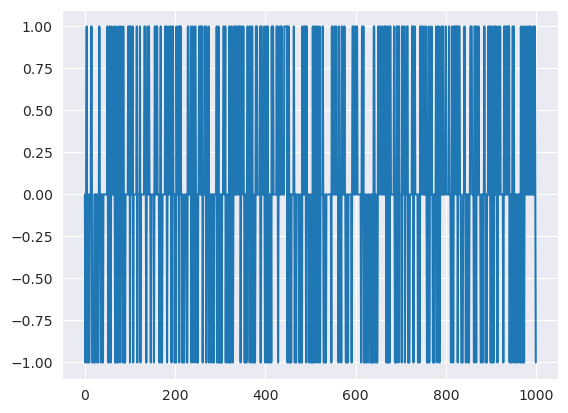

In [13]:
signal['A'].plot()